# Develop and test a QEC protocol (qodec)

Use `qdk` and `qodec` to develop and test a quantum error correction protocol. Start with the C4 code and build a baseline qodec. Then inspect its gadgets and improve them. Along the way, use `qdk`'s built-in profile and audit features to debug and validate.

## Executive summary

```python
from qdk import ec
from qdk.simulation import run_qir

c4 = qodec.Code(stabilizers=..., x=..., z=...)  # define a code
protocol = ec.build_qodec(c4, strategy=...)  # build a qodec
ec.audit(protocol)  # validate the qodec
results = run_qir(qir_program, qodec=protocol, ...)  # simulate a logical program
```

Section 7 checks QIR execution, then plots the isolated error rate and yield of all six C4 instructions under circuit-level noise. It uses 1,000 attempts per instruction and noise level for fast iterations.

## Install

```bash
pip install "qdk[ec]" matplotlib
```

## 1. Define your code

We will base our protocol on the $4$-qubit $[[4,2,2]]$ error-detecting code C4.
The C4 code stores two logical qubits in four physical qubits. Its two stabilizers are $XXXX$ and $ZZZZ$.

The `qodec` package is used to define the protocol; `qdk` provides the analysis.

In [1]:
import qodec

c4 = qodec.Code(
    "C4",
    stabilizers=["X_0 X_1 X_2 X_3", "Z_0 Z_1 Z_2 Z_3"],
    x=["X_0 X_1", "X_0 X_2"],
    z=["Z_0 Z_2", "Z_0 Z_1"],
)

Pauli strings in `qodec` use the sparse notation `P_i`, where `P` is one of the Pauli matrices `{X, Y, Z}` and `i` is the index of the qubit on which the Pauli acts.

### Check the code distance

We've defined the code. Now we'd like to make sure it's _correct_. In particular, it should have distance two.  QDK provides a `CodeProfile` that, among other things, can compute the code distance.

In [2]:
import qdk.ec as ec

code = ec.CodeProfile(c4)
code_distance = code.distance()
print("Code distance:", code_distance)

error = code_distance.witness.product
syndrome = code.syndrome_of(error)
effect = code.logical_effect_of(error)

print(f"Witness: {error}, (syndrome: {list(syndrome)}, logical effect: {effect})")
assert code_distance == error.weight == 2
assert code.is_logical(error)

Code distance: 2
Witness: XX, (syndrome: [], logical effect: X)


## 2. Build a baseline qodec

We have a code. But a code alone is a mathematical object: it doesn't describe how to _use_ it on a quantum computer. For that, we need a qodec, a formal description of an executable protocol.

Authoring a full qodec, including its instruction sets and gadgets, can be a substantial task. To get started, QDK provides `build_qodec`, which builds a baseline protocol from a code definition. There are many ways to do this; the `strategy` parameter selects the recipe.

We will use `bare-css/v1`, a strategy that measures syndromes with ancillas but adds no flag qubits.

The result has two layers: logical C4 operations and physical Stim operations. Each logical instruction has a _gadget_: a circuit that implements it using the next layer. Its encodings identify the physical qubits for each logical block; its equations describe checks and readouts.

Let's build the qodec and inspect the start of its YAML representation. Then we'll use `gadgets` to edit the protocol directly.

In [3]:
protocol = ec.build_qodec(c4, strategy="bare-css/v1", strict=False)
print(protocol.dumps()[:500], "...")

---
qodec.yaml:
  name: C4
  description: 'Built from the ''C4'' stabilizer code ([[4, 2]]). Strategy: bare-css/v1.'
  layers:
  - instruction_set: C4.isa.yaml
    codes:
      C4: C4.code.yaml
    gadgets:
      cx_all: cx_all.gadget.yaml
      measure_x_all: measure_x_all.gadget.yaml
      measure_z_all: measure_z_all.gadget.yaml
      prepare_x_all: prepare_x_all.gadget.yaml
      prepare_z_all: prepare_z_all.gadget.yaml
      syndrome: syndrome.gadget.yaml
  - instruction_set: stim.isa.yaml
 ...


### Inspect `prepare` instructions and gadgets

Let's look at `prepare_z_all` and its implementation together. The instruction produces one C4 block in logical $|00\rangle$. It has no input block and one output block, which encodes two logical qubits. The `stabilize` action requires both logical Z operators, `Z_0` and `Z_1`, to have eigenvalue +1.

In [4]:
instruction_set = protocol.layers[0].instruction_set
instruction_set.instructions["prepare_z_all"]

mnemonic: prepare_z_all
description: Prepare all 2 logical qubit(s) in |0⟩.
out: [C4]
action:
- stabilize: [Z_0, Z_1]


The instruction specifies the contract but does _not_ supply the implementation. That is the gadget's responsibility.  The corresponding `prepare_z_all` gadget is shown below.
It includes a circuit and parity checks. A _check_ is an equation that should evaluate to zero without faults. The equations include measurement bits and input/output encoding signs.

In [5]:
gadgets = protocol.layers[0].gadgets
gadgets["prepare_z_all"]

circuit:
  source: |
    R 0 1 2 3
    R 4
    H 4
    CX 4 0
    CX 4 1
    CX 4 2
    CX 4 3
    H 4
    R 5
    H 5
    CZ 5 0
    CZ 5 1
    CZ 5 2
    CZ 5 3
    H 5
    M 4 5
  format: stim
  out:
    '0': qubit
    '1': qubit
    '2': qubit
    '3': qubit
out:
- C4: [0, 1, 2, 3]
checks:
- ['circuit.readouts[1]']
- ['circuit.readouts[0]', 'out[0].stabilizers[0]']
- ['out[0].stabilizers[1]']


The circuit source is Stim (qodec supports any circuit representation with an associated parser). So we can use `stim` directly to look at the circuit.

In [6]:
import stim
stim.Circuit(gadgets["prepare_z_all"].circuit.source).diagram("timeline-svg-html")

<svg viewBox="0 0 992 480"  version="1.1" xmlns="http://www.w3.org/2000/svg">
<g id="qubit_lines">
<path id="qubit_line:0" d="M64,64 L960,64 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="64">q0</text>
<path id="qubit_line:1" d="M64,128 L960,128 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="128">q1</text>
<path id="qubit_line:2" d="M64,192 L960,192 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="192">q2</text>
<path id="qubit_line:3" d="M64,256 L960,256 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="256">q3</text>
<path id="qubit_line:4" d="M64,320 L960,320 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="320">q4</text>
<path id="qubit_line:5" d="M64,384 L960,384 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="384">q5</text>
</g>
<rect x="80" y="48" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="64" fill="white">R</text>
<rect x="80" y="112" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="128" fill="white">R</text>
<rect x="80" y="176" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="192" fill="white">R</text>
<rect x="80" y="240" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="256" fill="white">R</text>
<rect x="80" y="304" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="320" fill="white">R</text>
<rect x="144" y="304" width="32" height="32" stroke="black" fill="white"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="160" y="320">H</text>
<path d="M224,64 L224,320 " stroke="black"/>
<circle cx="224" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="224" cy="64" r="12" stroke="black" fill="white"/>
<path d="M212,64 L236,64 M224,52 L224,76 " stroke="black"/>
<path d="M288,128 L288,320 " stroke="black"/>
<circle cx="288" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="288" cy="128" r="12" stroke="black" fill="white"/>
<path d="M276,128 L300,128 M288,116 L288,140 " stroke="black"/>
<path d="M352,192 L352,320 " stroke="black"/>
<circle cx="352" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="352" cy="192" r="12" stroke="black" fill="white"/>
<path d="M340,192 L364,192 M352,180 L352,204 " stroke="black"/>
<path d="M416,256 L416,320 " stroke="black"/>
<circle cx="416" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="416" cy="256" r="12" stroke="black" fill="white"/>
<path d="M404,256 L428,256 M416,244 L416,268 " stroke="black"/>
<rect x="464" y="304" width="32" height="32" stroke="black" fill="white"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="480" y="320">H</text>
<rect x="464" y="368" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="480" y="384" fill="white">R</text>
<rect x="528" y="368" width="32" height="32" stroke="black" fill="white"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="544" y="384">H</text>
<path d="M608,64 L608,384 " stroke="black"/>
<circle cx="608" cy="384" r="12" s

Does this circuit prepare the state that the instruction claims it does? As with `CodeProfile`, we can use a `GadgetProfile` to analyze it. Its `objective` is the declared instruction; its `action` is the behavior computed from the circuit. Let's inspect the computed action and check that it matches the instruction.

In [7]:
from IPython.display import Markdown, display


def display_gadget_action(profile: ec.GadgetProfile) -> None:
    objective, action = profile.objective, profile.action
    if objective is None:
        result = "**Comparison unavailable:** no declared operation."
    elif action.is_equivalent_to(objective):
        result = "**Meets objective:** ✓"
    else:
        result = f"**Meets objective:** ✗\n\n{objective.why_not_equivalent_to(action)}"
    display(Markdown(f"**Computed action**\n\n```text\n{action}\n```\n\n{result}"))


preparation_profile = ec.GadgetProfile(gadgets["prepare_z_all"])
display_gadget_action(preparation_profile)

**Computed action**

```text
stabilizers:
  Z_0 = +1
  Z_1 = +1
```

**Meets objective:** ✓

### Inspect `cx`

Now let's look at `cx_all`. It takes two C4 blocks and applies CNOT between corresponding logical qubits. The `action` treats qubit indices as flat. The first C4 block corresponds to indices 0 and 1. The second C4 block corresponds to indices 2 and 3.

In [8]:
instruction_set.instructions["cx_all"]

mnemonic: cx_all
description: CNOT from the first block to the second, pairing logical qubits.
in: [C4, C4]
out: [C4, C4]
action:
- clifford:
    X_0: X_0 X_2
    X_1: X_1 X_3
    Z_2: Z_0 Z_2
    Z_3: Z_1 Z_3


Now, let's inspect the corresponding CNOT gadget. 

In [9]:
gadgets["cx_all"]

circuit:
  source: |
    CX 0 4
    CX 1 5
    CX 2 6
    CX 3 7
  format: stim
  in:
    '0': qubit
    '1': qubit
    '2': qubit
    '3': qubit
    '4': qubit
    '5': qubit
    '6': qubit
    '7': qubit
  out:
    '0': qubit
    '1': qubit
    '2': qubit
    '3': qubit
    '4': qubit
    '5': qubit
    '6': qubit
    '7': qubit
in:
- C4: [0, 1, 2, 3]
- C4: [4, 5, 6, 7]
out:
- C4: [0, 1, 2, 3]
- C4: [4, 5, 6, 7]
checks:
- ['out[0].stabilizers[0]', 'in[0].stabilizers[0]', 'in[1].stabilizers[0]']
- ['out[0].stabilizers[1]', 'in[0].stabilizers[1]']
- ['out[1].stabilizers[0]', 'in[1].stabilizers[0]']
- ['out[1].stabilizers[1]', 'in[0].stabilizers[1]', 'in[1].stabilizers[1]']


The circuit is very simple: just transversal CNOTs across the two 4-qubit physical blocks. The `in/out` fields specify how to connect circuit labels to the logical blocks.
Note that, even though this gadget has no readouts, it _does_ include parity checks. The parity checks here relate the input stabilizers to the output stabilizers.

Next, we can look at the action of the gadget and verify that it implements the intended instruction.

In [10]:
cnot_profile = ec.GadgetProfile(gadgets["cx_all"])
display_gadget_action(cnot_profile)

**Computed action**

```text
mapping:
  X_0 → X_0 X_2
  Z_0 → Z_0
  X_1 → X_1 X_3
  Z_1 → Z_1
  X_2 → X_2
  Z_2 → Z_0 Z_2
  X_3 → X_3
  Z_3 → Z_1 Z_3
```

**Meets objective:** ✓

## 3. Check the entire qodec for correctness

We've inspected two instructions and their gadgets. Now we'd like to check the whole protocol. QDK provides `audit` to compare the circuits with their declared operations and equations. The audit should report no errors or warnings for the generated protocol. 

To see what the audit can tell us, we will deliberately remove some equations. The circuits will stay the same. Then we'll use QDK to derive the missing equations and check the protocol again.

In [11]:
report = ec.audit(protocol)
print(report)

audit: ok


### Remove the measurement readouts

The `measure_x_all` gadget should report two logical measurement results. Its readout equations tell us which physical measurement bits and frame signs to combine for each result.

Let's clear those equations. The circuit still measures the qubits, but the protocol no longer defines its logical results. The audit should report two `gadget/missing-observable` errors and show where the equations are missing.

In [12]:
gadgets["measure_x_all"].readouts.clear()
print(ec.audit(protocol))

[ERROR] gadget/missing-observable
layers[0].gadgets['measure_x_all'] (C4 -> stim)
readouts[0] has no equation for the required logical X_0 measurement
    Verified readout equation: ["in[0].x[0]", "circuit.readouts[0]", "circuit.readouts[1]"]

[ERROR] gadget/missing-observable
layers[0].gadgets['measure_x_all'] (C4 -> stim)
readouts[1] has no equation for the required logical X_1 measurement
    Verified readout equation: ["in[0].x[1]", "circuit.readouts[0]", "circuit.readouts[2]"]

audit: 2 error(s), 0 warning(s), 0 informational


### Remove the CNOT checks

Now let's remove the four checks from `cx_all`. These relate the input and output stabilizer signs. The circuit still performs the logical CNOT, but we have removed the equations that specify its output stabilizer signs. The audit should add four `gadget/incomplete-output-frame` warnings to the two readout errors.

In [13]:
gadgets["cx_all"].checks.clear()
print(ec.audit(protocol))

[ERROR] gadget/missing-observable
layers[0].gadgets['measure_x_all'] (C4 -> stim)
readouts[0] has no equation for the required logical X_0 measurement
    Verified readout equation: ["in[0].x[0]", "circuit.readouts[0]", "circuit.readouts[1]"]

[ERROR] gadget/missing-observable
layers[0].gadgets['measure_x_all'] (C4 -> stim)
readouts[1] has no equation for the required logical X_1 measurement
    Verified readout equation: ["in[0].x[1]", "circuit.readouts[0]", "circuit.readouts[2]"]

[WARNING] gadget/incomplete-output-frame
layers[0].gadgets['cx_all'] (C4 -> stim)
Declared relations do not determine out[0].stabilizers[0] (X_0 X_1 X_2 X_3)
    Code: C4; circuit support: ['0', '1', '2', '3'].
    Verified relation: ["out[0].stabilizers[0]", "in[0].stabilizers[0]", "in[1].stabilizers[0]"]

[WARNING] gadget/incomplete-output-frame
layers[0].gadgets['cx_all'] (C4 -> stim)
Declared relations do not determine out[0].stabilizers[1] (Z_0 Z_1 Z_2 Z_3)
    Code: C4; circuit support: ['0', '1', '2'

Replacing the missing gadget information can be tedious.  For situations like these, QDK offers `filled`.  This function accepts a partial qodec (or gadget) and attempts to fill it in based on the existing contents.

In [14]:
protocol = ec.filled(protocol)
gadgets = protocol.layers[0].gadgets
print(ec.audit(protocol))

audit: ok


## 4. Check the gadgets for fault tolerance

The qodec passes the audit. But the audit doesn't consider fault tolerance. What happens when a circuit has faults?

We checked the code distance in section 1. Now we will use `GadgetProfile.distance()` to check the _gadget distance_: the fewest allowed circuit faults that change the logical action, stay within the output codespaces, and leave every check and flag zero.

The default model is circuit noise: a Pauli error after a call, a flip of that call's recorded readout bits, or both.

Let's compute the distance of each gadget. Each result includes a _witness_: a set of faults that achieves the reported distance.

In [15]:
def report_gadget_distances(protocol: qodec.Qodec) -> None:
    distances = {
        mnemonic: ec.GadgetProfile(gadget).distance()
        for mnemonic, gadget in protocol.layers[0].gadgets.items()
    }
    rows = [
        "| Gadget | Distance | Witness |",
        "| --- | ---: | --- |",
    ]
    rows.extend(
        f"| `{mnemonic}` | {distance} | {distance.witness} |"
        for mnemonic, distance in sorted(distances.items())
    )
    display(Markdown("\n".join(rows)))

report_gadget_distances(protocol)

| Gadget | Distance | Witness |
| --- | ---: | --- |
| `cx_all` | 2 | X_4 after call 0; X_5 after call 1 |
| `measure_x_all` | 2 | X_0 after call 0; X_1 after call 1 |
| `measure_z_all` | 2 | flip call 0 readout 0; flip call 1 readout 0 |
| `prepare_x_all` | 1 | X_5 after call 18 |
| `prepare_z_all` | 1 | X_4 after call 7 |
| `syndrome` | 1 | X_4 after call 3 |

We're using a distance-two code, so we might hope that our gadgets also achieve distance two. Some of them do, but the `prepare` and `syndrome` gadgets do not. We fix that in the next section.

## 5. Increase the gadget distances

### Why the syndrome gadget has distance one

Let's inspect the `syndrome` circuit and the distance-one witness.


In [16]:
from IPython.display import HTML, display

circuit = gadgets["syndrome"].circuit
diagram = str(stim.Circuit(circuit.source).diagram("timeline-svg-html"))
call_text = "\n".join(
    f"{index}: {call.mnemonic} {call.operands}"
    for index, call in enumerate(circuit.calls())
)

display(HTML(
    '<div style="display:flex;gap:2rem;flex-wrap:wrap">'
    f'<pre>{diagram}</pre>'
    f'<pre>{call_text}</pre>'
    '</div>'
))


Ancilla 4 measures the X stabilizer with CNOTs. Ancilla 5 then measures the Z stabilizer with controlled-Z gates. We will follow faults on these ancillas through the remaining gates and inspect which checks and output signs they change.

In [17]:
idle_profile = ec.GadgetProfile(gadgets["syndrome"])
calls = gadgets["syndrome"].circuit.calls()
distance = idle_profile.distance()
location = distance.witness.product.locations[0]
call = calls[location.after_call]
effect = idle_profile.effects_of([distance.witness.product])[0]
print(f"{distance.witness} ({call.mnemonic} {call.operands}) → {effect}")

X_4 after call 3 (CX [4, 1]) → ['out[0].z[0]']


The offending fault occurs on the third call of the gadget, `CX 4 1`. It spreads through subsequent `CX` gates, ultimately flipping the output `z[0]` observable, but _not_ flipping the Z-stabilizer measurement. It is a logical `X_0` error.

But that's not the only problematic fault. The distance has several witnesses, which we examine below.

In [18]:
faults = [witness.product for witness in distance.witnesses]
effects = idle_profile.effects_of(faults)

for fault, effect in zip(faults, effects):
    location = fault.locations[0]
    call = calls[location.after_call]
    print(f"{fault}\t({call.mnemonic} {call.operands})\t→ {effect}")

X_4 after call 3	(CX [4, 1])	→ ['out[0].z[0]']
X_2 X_4 after call 4	(CX [4, 2])	→ ['out[0].z[0]']
X_5 after call 10	(CZ [5, 1])	→ ['out[0].x[1]']
Z_2 X_5 after call 11	(CZ [5, 2])	→ ['out[0].x[1]']


### Improve the syndrome circuit

All of the problematic faults are errors that occur on an ancilla qubit and then spread to multiple data qubits and go undetected. We need a circuit that avoids this phenomenon.
In this case, a circuit by [Reichardt](https://arxiv.org/pdf/1804.06995#page=4) does the trick. It interleaves the ancilla interactions so that any dangerous error spreads to the other ancilla's measurement result. It uses eight CNOTs and the same two ancillas, without adding a flag qubit.

Let's replace our circuit with Reichardt's. Then we'll use `filled` to recompute the parity checks and evaluate the new gadget distance.

In [19]:
reichardt_source = """
R 4 5
H 4
CX 4 0
CX 2 5
CX 0 5
CX 1 5
CX 4 2
CX 4 3
CX 4 1
CX 3 5
H 4
M 4 5
"""
display(stim.Circuit(reichardt_source).diagram("timeline-svg-html"))

gadgets["syndrome"].circuit.source = reichardt_source
gadgets["syndrome"] = ec.filled(gadgets["syndrome"])

improved_syndrome_profile = ec.GadgetProfile(gadgets["syndrome"])
print("Improved syndrome distance:", improved_syndrome_profile.distance())
print(ec.audit(protocol))

<svg viewBox="0 0 864 480"  version="1.1" xmlns="http://www.w3.org/2000/svg">
<g id="qubit_lines">
<path id="qubit_line:0" d="M64,64 L832,64 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="64">q0</text>
<path id="qubit_line:1" d="M64,128 L832,128 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="128">q1</text>
<path id="qubit_line:2" d="M64,192 L832,192 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="192">q2</text>
<path id="qubit_line:3" d="M64,256 L832,256 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="256">q3</text>
<path id="qubit_line:4" d="M64,320 L832,320 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="320">q4</text>
<path id="qubit_line:5" d="M64,384 L832,384 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="384">q5</text>
</g>
<rect x="80" y="304" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="320" fill="white">R</text>
<rect x="80" y="368" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="384" fill="white">R</text>
<rect x="144" y="304" width="32" height="32" stroke="black" fill="white"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="160" y="320">H</text>
<path d="M224,64 L224,320 " stroke="black"/>
<circle cx="224" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="224" cy="64" r="12" stroke="black" fill="white"/>
<path d="M212,64 L236,64 M224,52 L224,76 " stroke="black"/>
<path d="M288,192 L288,384 " stroke="black"/>
<circle cx="288" cy="192" r="12" stroke="none" fill="black"/>
<circle cx="288" cy="384" r="12" stroke="black" fill="white"/>
<path d="M276,384 L300,384 M288,372 L288,396 " stroke="black"/>
<path d="M352,64 L352,384 " stroke="black"/>
<circle cx="352" cy="64" r="12" stroke="none" fill="black"/>
<circle cx="352" cy="384" r="12" stroke="black" fill="white"/>
<path d="M340,384 L364,384 M352,372 L352,396 " stroke="black"/>
<path d="M416,128 L416,384 " stroke="black"/>
<circle cx="416" cy="128" r="12" stroke="none" fill="black"/>
<circle cx="416" cy="384" r="12" stroke="black" fill="white"/>
<path d="M404,384 L428,384 M416,372 L416,396 " stroke="black"/>
<path d="M480,192 L480,320 " stroke="black"/>
<circle cx="480" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="480" cy="192" r="12" stroke="black" fill="white"/>
<path d="M468,192 L492,192 M480,180 L480,204 " stroke="black"/>
<path d="M544,256 L544,320 " stroke="black"/>
<circle cx="544" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="544" cy="256" r="12" stroke="black" fill="white"/>
<path d="M532,256 L556,256 M544,244 L544,268 " stroke="black"/>
<path d="M608,128 L608,320 " stroke="black"/>
<circle cx="608" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="608" cy="128" r="12" stroke="black" fill="white"/>
<path d="M596,128 L620,128 M608,116 L608,140 " stroke="black"/>
<path d="M672,256 L672,384 " stroke="black"/>
<circle cx="672" cy="256" r="12" stroke="none" fill="black"/>
<circle cx="672" cy="384" r="12" stroke="black" fill="white"/>
<path d="M660,384 L684,384 M672,372 L672,396 " stroke="black"/>
<rect x="720" y="304" width="32" height="32" stroke="black" fill="white"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="736" y="320">H</text>
<rect x="784" y="304" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" f

Improved syndrome distance: 2
audit: ok


### Detect analogous hook faults

The reordered circuit still lets an ancilla fault spread to two data qubits, but the other ancilla now detects it. The gadget distance of two is proof.

But it's possible to see this improvement explicitly by looking at how previously dangerous ancilla faults impact the new circuit.

In [20]:
improved_calls = gadgets["syndrome"].circuit.calls()
faults = [
    ec.FaultEvent.after(5, ec.Pauli("Z_5")),  
    ec.FaultEvent.after(7, ec.Pauli("X_4"))
]
effects = improved_syndrome_profile.effects_of(faults)

for fault, effect in zip(faults, effects):
    call = improved_calls[fault.locations[0].after_call]
    print(f"{fault} ({call.mnemonic} {call.operands}) →")
    for reference in effect.checks + effect.readouts:
        equation = gadgets["syndrome"].resolve(reference).value(tuple)
        print(f"  {reference} = {[str(term) for term in equation]}")
    for reference in effect.frames:
        print(f"  {reference}")
    print()

Z_5 after call 5 (CX [0, 5]) →
  checks[0] = ['circuit.readouts[0]', 'in[0].stabilizers[0]']
  checks[2] = ['circuit.readouts[0]', 'out[0].stabilizers[0]']
  out[0].x[0]

X_4 after call 7 (CX [4, 2]) →
  checks[1] = ['circuit.readouts[1]', 'in[0].stabilizers[1]']
  checks[3] = ['circuit.readouts[1]', 'out[0].stabilizers[1]']
  out[0].z[1]



The faults still flip logical operators (`Z_5` flips `out[0].x[0]`, `X_4` flips `out[0].z[1]`). But now, those faults are detected by parity checks, thereby increasing the distance.

### Improve both preparations with a flag

The `syndrome` gadget now looks good. We also need to improve the `prepare` gadgets. Let's look at the $|00\rangle$ circuit.

In [21]:
stim.Circuit(gadgets["prepare_z_all"].circuit.source).diagram("timeline-svg-html")

<svg viewBox="0 0 992 480"  version="1.1" xmlns="http://www.w3.org/2000/svg">
<g id="qubit_lines">
<path id="qubit_line:0" d="M64,64 L960,64 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="64">q0</text>
<path id="qubit_line:1" d="M64,128 L960,128 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="128">q1</text>
<path id="qubit_line:2" d="M64,192 L960,192 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="192">q2</text>
<path id="qubit_line:3" d="M64,256 L960,256 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="256">q3</text>
<path id="qubit_line:4" d="M64,320 L960,320 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="320">q4</text>
<path id="qubit_line:5" d="M64,384 L960,384 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="384">q5</text>
</g>
<rect x="80" y="48" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="64" fill="white">R</text>
<rect x="80" y="112" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="128" fill="white">R</text>
<rect x="80" y="176" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="192" fill="white">R</text>
<rect x="80" y="240" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="256" fill="white">R</text>
<rect x="80" y="304" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="320" fill="white">R</text>
<rect x="144" y="304" width="32" height="32" stroke="black" fill="white"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="160" y="320">H</text>
<path d="M224,64 L224,320 " stroke="black"/>
<circle cx="224" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="224" cy="64" r="12" stroke="black" fill="white"/>
<path d="M212,64 L236,64 M224,52 L224,76 " stroke="black"/>
<path d="M288,128 L288,320 " stroke="black"/>
<circle cx="288" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="288" cy="128" r="12" stroke="black" fill="white"/>
<path d="M276,128 L300,128 M288,116 L288,140 " stroke="black"/>
<path d="M352,192 L352,320 " stroke="black"/>
<circle cx="352" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="352" cy="192" r="12" stroke="black" fill="white"/>
<path d="M340,192 L364,192 M352,180 L352,204 " stroke="black"/>
<path d="M416,256 L416,320 " stroke="black"/>
<circle cx="416" cy="320" r="12" stroke="none" fill="black"/>
<circle cx="416" cy="256" r="12" stroke="black" fill="white"/>
<path d="M404,256 L428,256 M416,244 L416,268 " stroke="black"/>
<rect x="464" y="304" width="32" height="32" stroke="black" fill="white"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="480" y="320">H</text>
<rect x="464" y="368" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="480" y="384" fill="white">R</text>
<rect x="528" y="368" width="32" height="32" stroke="black" fill="white"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="544" y="384">H</text>
<path d="M608,64 L608,384 " stroke="black"/>
<circle cx="608" cy="384" r="12" s

This circuit is nearly identical to our original `syndrome` circuit, and so it's subject to the same problems: a fault on an ancilla spreads to an undetected logical error.

We'll fix this by instead using a unitary encoding circuit and a _flag_. A flag is a special parity check that gets promoted to a readout. It can then be used to reject noisy states, a process known as pre-selection.
Below, we add a `reject` flag to each gadget and bind it to the measurement. The `GadgetProfile.distance` calculation accounts for the flag automatically.

The $|++\rangle$ preparation is identical to the $|00\rangle$ preparation followed by transversal Hadamard gates.


In [22]:
flagged_preparation_source = """R 0 1 2 3 4
H 0
CX 0 4
CX 0 1
CX 0 2
CX 0 3
CX 0 4
"""
preparation_suffixes = {
    "prepare_z_all": "M 4\n",
    "prepare_x_all": "H 0 1 2 3\nM 4\n",
}
for mnemonic, suffix in preparation_suffixes.items():
    gadget = gadgets[mnemonic]
    gadget.implements.flags = ["reject"]
    gadget.circuit.source = flagged_preparation_source + suffix
    gadget.readouts = [{"reject": ["circuit.readouts[0]"]}]
    gadgets[mnemonic] = ec.filled(gadget)
    print(mnemonic, "distance:", ec.GadgetProfile(gadgets[mnemonic]).distance())
print(ec.audit(protocol))

prepare_z_all distance: 2
prepare_x_all distance: 2
audit: ok


In [23]:
stim.Circuit(gadgets["prepare_z_all"].circuit.source).diagram("timeline-svg-html")

<svg viewBox="0 0 608 416"  version="1.1" xmlns="http://www.w3.org/2000/svg">
<g id="qubit_lines">
<path id="qubit_line:0" d="M64,64 L576,64 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="64">q0</text>
<path id="qubit_line:1" d="M64,128 L576,128 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="128">q1</text>
<path id="qubit_line:2" d="M64,192 L576,192 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="192">q2</text>
<path id="qubit_line:3" d="M64,256 L576,256 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="256">q3</text>
<path id="qubit_line:4" d="M64,320 L576,320 " stroke="black"/>
<text dominant-baseline="central" text-anchor="end" font-family="monospace" font-size="12" x="64" y="320">q4</text>
</g>
<rect x="80" y="48" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="64" fill="white">R</text>
<rect x="80" y="112" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="128" fill="white">R</text>
<rect x="80" y="176" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="192" fill="white">R</text>
<rect x="80" y="240" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="256" fill="white">R</text>
<rect x="80" y="304" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="96" y="320" fill="white">R</text>
<rect x="144" y="48" width="32" height="32" stroke="black" fill="white"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="160" y="64">H</text>
<path d="M224,64 L224,320 " stroke="black"/>
<circle cx="224" cy="64" r="12" stroke="none" fill="black"/>
<circle cx="224" cy="320" r="12" stroke="black" fill="white"/>
<path d="M212,320 L236,320 M224,308 L224,332 " stroke="black"/>
<path d="M288,64 L288,128 " stroke="black"/>
<circle cx="288" cy="64" r="12" stroke="none" fill="black"/>
<circle cx="288" cy="128" r="12" stroke="black" fill="white"/>
<path d="M276,128 L300,128 M288,116 L288,140 " stroke="black"/>
<path d="M352,64 L352,192 " stroke="black"/>
<circle cx="352" cy="64" r="12" stroke="none" fill="black"/>
<circle cx="352" cy="192" r="12" stroke="black" fill="white"/>
<path d="M340,192 L364,192 M352,180 L352,204 " stroke="black"/>
<path d="M416,64 L416,256 " stroke="black"/>
<circle cx="416" cy="64" r="12" stroke="none" fill="black"/>
<circle cx="416" cy="256" r="12" stroke="black" fill="white"/>
<path d="M404,256 L428,256 M416,244 L416,268 " stroke="black"/>
<path d="M480,64 L480,320 " stroke="black"/>
<circle cx="480" cy="64" r="12" stroke="none" fill="black"/>
<circle cx="480" cy="320" r="12" stroke="black" fill="white"/>
<path d="M468,320 L492,320 M480,308 L480,332 " stroke="black"/>
<rect x="528" y="304" width="32" height="32" stroke="black" fill="black"/>
<text dominant-baseline="central" text-anchor="middle" font-family="monospace" font-size="30" x="544" y="320" fill="white">M</text>
<text text-anchor="middle" font-family="monospace" font-size="8" x="544" y="300">rec[0]</text>
</svg>

## 6. Inspect and save the improved qodec

We've changed the syndrome and preparation circuits. Now let's check the whole qodec again. The audit should report no errors or warnings, and all six gadgets should have distance two.

In [24]:
protocol.description = (
    "C4 built with bare-css/v1, with self-checking syndrome extraction "
    "and single-flag preparation circuits."
)
print(ec.audit(protocol))
report_gadget_distances(protocol);

audit: ok


| Gadget | Distance | Witness |
| --- | ---: | --- |
| `cx_all` | 2 | X_4 after call 0; X_5 after call 1 |
| `measure_x_all` | 2 | X_0 after call 0; X_1 after call 1 |
| `measure_z_all` | 2 | flip call 0 readout 0; flip call 1 readout 0 |
| `prepare_x_all` | 2 | X_1 after call 1; X_2 after call 2 |
| `prepare_z_all` | 2 | X_1 after call 1; X_2 after call 2 |
| `syndrome` | 2 | X_4 after call 0; Z_5 after call 5 |

### Save the qodec

We now have a qodec we'd like to keep. Use `save` to write its circuits and declarations into one YAML bundle.

In [25]:
from tempfile import TemporaryDirectory

with TemporaryDirectory() as directory:
    saved_path = protocol.save(directory, single_file=True)
    assert qodec.Qodec.load(saved_path) == protocol
print("Round trip: OK")

Round trip: OK


## 7. Evaluate performance

First check that `qdk.simulation.run_qir` executes the improved protocol from section 6. The Q# program prepares a logical $|0\rangle$ and measures it in the Z basis. Every returned result should be `Zero` in this noiseless check.

The runner gives this program qubit its own C4 block. Both logical qubits are prepared and measured, but the program returns only logical qubit 0's result. This checks `prepare_z_all`, `measure_z_all`, and the default syndrome decoder. The isolated benchmarks below instead cover every instruction and both logical qubits.

In [30]:
from itertools import product
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
from scipy.stats import binomtest
from qdk import Result, TargetProfile, qsharp
from qdk.simulation import run_qir

qsharp.init(target_profile=TargetProfile.Base)
qir_program = qsharp.compile("{ use q = Qubit(); M(q) }")

### Check the noiseless result

Every shot should return `Zero`. Use `on_shot_failure="raise"` here so a rejected or undecodable shot fails the check rather than disappearing from the results.

In [31]:
noiseless_shots = 20
noiseless_results = run_qir(
    qir_program,
    shots=noiseless_shots,
    seed=7,
    type="clifford",
    qodec=protocol,
    on_shot_failure="raise",
)
assert noiseless_results == [Result.Zero] * noiseless_shots
print(f"Noiseless check: {noiseless_shots} correct shots, none discarded.")

Noiseless check: 20 correct shots, none discarded.


### Isolate each instruction under circuit-level noise

For example, the `cx_all` benchmark starts with ideal encoded inputs, adds faults only to its four physical CX gates, and checks the outputs ideally. Its yield does not include the cost of preparing or measuring those blocks. The other five instructions use the same ideal-boundary convention.

Use independent circuit-level noise with fault probability $p$ at each physical location:

- After each H: X, Y, or Z, each with probability $p/3$.
- After each CX: one of the 15 nonidentity two-qubit Paulis, each with probability $p/15$.
- After each Z reset: X with probability $p$ (preparation of the wrong eigenstate).
- At each Z measurement: flip the reported bit with probability $p$.

There are no scheduled idle locations in these circuits, so idle, leakage, loss, and correlated faults are not included. Input preparation and external boundary checks are noiseless. These are the only physical gate kinds used by the six gadgets; the code raises if a new kind appears.

Accept an attempt only when every declared check and flag is zero. Checks that refer to output stabilizers use ideal output-code measurements. Thus this yield includes ideal boundary postselection; it is not the yield of the runtime decoder. A logical error on an accepted attempt means:

- `prepare_z_all` / `prepare_x_all`: a wrong Z / X eigenvalue on either logical qubit. A phase that leaves the prepared state unchanged is harmless.
- `measure_z_all` / `measure_x_all`: either logical measurement bit is wrong.
- `cx_all` / `syndrome`: any logical X or Z mapping is wrong, on either logical qubit of any output block.

For these Clifford circuits, fault effects combine by XOR, including cancellations. `GadgetProfile.effects_of` computes each possible local fault's check, flag, and logical-sign changes once; sampling the resulting tables is then fast. This tests logical action, not just a chosen input state's Z readout. It does not use `run_qir` or a correction decoder for the isolated sweep.

Each attempt is counted once, without retries or confidence-based selection. The current runtime's `select` condition rejects mismatching flags; it does not repeat that instruction. `on_shot_failure="retry"` retries the whole program. Instruction-local retries and decoder-confidence selection remain separate work.

In [32]:
def circuit_fault_choices(gadget: qodec.Gadget) -> list[tuple[ec.FaultEvent, ...]]:
    choices = []
    arities = {"R": 1, "M": 1, "H": 1, "CX": 2}
    for index, call in enumerate(gadget.circuit.calls()):
        if call.mnemonic not in arities or call.arguments or call.select:
            raise ValueError(f"Unsupported noise location: {call}")
        if len(call.operands) != arities[call.mnemonic]:
            raise ValueError(f"Unexpected gate arity: {call}")
        if call.mnemonic == "M":
            choices.append((ec.FaultEvent.after(index, readout_flips=0),))
            continue
        paulis = ("X",) if call.mnemonic == "R" else (
            "".join(chars)
            for chars in product("IXYZ", repeat=len(call.operands))
            if any(char != "I" for char in chars)
        )
        choices.append(tuple(
            ec.FaultEvent.after(index, ec.Pauli(" ".join(
                f"{char}_{qubit}" for char, qubit in zip(pauli, call.operands)
                if char != "I"
            )))
            for pauli in paulis
        ))
    return choices


def instruction_fault_tables(
    gadget: qodec.Gadget, logical_references: list[str]
) -> tuple[list[NDArray[np.bool_]], int]:
    reject_references = [f"checks[{i}]" for i in range(len(gadget.checks))]
    reject_references += [
        f"readouts[{i}]" for i, readout in enumerate(gadget.readouts)
        if readout.is_flag
    ]
    references = reject_references + logical_references
    choices = circuit_fault_choices(gadget)
    effects = ec.GadgetProfile(gadget).effects_of([
        fault for site in choices for fault in site
    ])
    rows = np.array([
        [reference in effect for reference in references] for effect in effects
    ], dtype=bool)
    tables = []
    offset = 0
    for site in choices:
        tables.append(np.vstack((
            np.zeros(len(references), dtype=bool),
            rows[offset:offset + len(site)],
        )))
        offset += len(site)
    return tables, len(reject_references)


def sample_instruction(
    tables: list[NDArray[np.bool_]], probability: float, *, shots: int, seed: int
) -> NDArray[np.bool_]:
    if not 0 <= probability <= 1:
        raise ValueError("Fault probability must be between zero and one.")
    if shots < 1:
        raise ValueError("The number of attempts must be positive.")
    rng = np.random.default_rng(seed)
    flips = np.zeros((shots, tables[0].shape[1]), dtype=bool)
    for table in tables:
        occurs = rng.random(shots) < probability
        choice = rng.integers(1, len(table), size=shots)
        flips ^= table[choice] & occurs[:, None]
    return flips

### Define the logical tests and check zero noise

The references below specify which logical signs must be unchanged for each instruction. Keep the instruction set exact: adding a gadget requires adding its logical test. Check both zero noise and every single local fault before sampling combinations.

In [33]:
logical_references = {
    "prepare_z_all": [f"out[0].z[{i}]" for i in range(2)],
    "prepare_x_all": [f"out[0].x[{i}]" for i in range(2)],
    "measure_z_all": [f"readouts[{i}]" for i in range(2)],
    "measure_x_all": [f"readouts[{i}]" for i in range(2)],
    "cx_all": [
        f"out[{block}].{basis}[{i}]"
        for block in range(2) for basis in ("x", "z") for i in range(2)
    ],
    "syndrome": [
        f"out[0].{basis}[{i}]" for basis in ("x", "z") for i in range(2)
    ],
}
gadgets = protocol.layers[0].gadgets
assert set(gadgets) == set(logical_references)
instruction_models = {
    name: instruction_fault_tables(gadgets[name], references)
    for name, references in logical_references.items()
}
for name, (tables, reject_count) in instruction_models.items():
    assert not sample_instruction(tables, 0, shots=20, seed=7).any(), name
    singles = np.concatenate([table[1:] for table in tables])
    accepted = ~singles[:, :reject_count].any(axis=1)
    wrong = singles[:, reject_count:].any(axis=1)
    assert not (accepted & wrong).any(), name
print("All six instructions: zero-noise checks pass; no single local fault is an accepted logical error.")

All six instructions: zero-noise checks pass; no single local fault is an accepted logical error.


### Sample error rate and yield

Use 1,000 attempts per instruction per noise level while iterating. Reuse the fault tables when changing the sweep or shot count; rebuild them after changing a gadget. Yield is accepted / attempted, and conditional logical error rate is wrong / accepted.

In [34]:
fault_probabilities = [1e-3, 3e-3, 1e-2, 3e-2, 5e-2]
shots_per_point = 1_000
sweep = []
started = perf_counter()
for instruction_index, (name, (tables, reject_count)) in enumerate(instruction_models.items()):
    for probability_index, probability in enumerate(fault_probabilities):
        flips = sample_instruction(
            tables, probability, shots=shots_per_point,
            seed=42 + instruction_index * len(fault_probabilities) + probability_index,
        )
        accepted = ~flips[:, :reject_count].any(axis=1)
        wrong = flips[:, reject_count:].any(axis=1)
        accepted_count = int(accepted.sum())
        if accepted_count == 0:
            raise RuntimeError(f"No {name} shots accepted at p={probability:g}.")
        sweep.append({
            "instruction": name,
            "fault_probability": probability,
            "attempted": shots_per_point,
            "accepted": accepted_count,
            "wrong": int((accepted & wrong).sum()),
            "discarded": shots_per_point - accepted_count,
        })
print(f"Sampled {len(sweep) * shots_per_point:,} attempts in {perf_counter() - started:.3f} s.")
rows = [
    "| Instruction | Fault probability | Attempted | Accepted | Logical errors | Discarded |",
    "| :--- | ---: | ---: | ---: | ---: | ---: |",
]
rows.extend(
    f"| `{point['instruction']}` | {point['fault_probability']:.4g} | {point['attempted']} | "
    f"{point['accepted']} | {point['wrong']} | {point['discarded']} |"
    for point in sweep
)
display(Markdown("\n".join(rows)))

Sampled 30,000 attempts in 0.017 s.


| Instruction | Fault probability | Attempted | Accepted | Logical errors | Discarded |
| :--- | ---: | ---: | ---: | ---: | ---: |
| `prepare_z_all` | 0.001 | 1000 | 988 | 0 | 12 |
| `prepare_z_all` | 0.003 | 1000 | 975 | 0 | 25 |
| `prepare_z_all` | 0.01 | 1000 | 899 | 0 | 101 |
| `prepare_z_all` | 0.03 | 1000 | 731 | 2 | 269 |
| `prepare_z_all` | 0.05 | 1000 | 575 | 7 | 425 |
| `prepare_x_all` | 0.001 | 1000 | 991 | 0 | 9 |
| `prepare_x_all` | 0.003 | 1000 | 966 | 0 | 34 |
| `prepare_x_all` | 0.01 | 1000 | 852 | 0 | 148 |
| `prepare_x_all` | 0.03 | 1000 | 649 | 10 | 351 |
| `prepare_x_all` | 0.05 | 1000 | 504 | 13 | 496 |
| `measure_z_all` | 0.001 | 1000 | 992 | 0 | 8 |
| `measure_z_all` | 0.003 | 1000 | 991 | 0 | 9 |
| `measure_z_all` | 0.01 | 1000 | 963 | 1 | 37 |
| `measure_z_all` | 0.03 | 1000 | 892 | 7 | 108 |
| `measure_z_all` | 0.05 | 1000 | 835 | 9 | 165 |
| `measure_x_all` | 0.001 | 1000 | 996 | 0 | 4 |
| `measure_x_all` | 0.003 | 1000 | 981 | 0 | 19 |
| `measure_x_all` | 0.01 | 1000 | 919 | 2 | 81 |
| `measure_x_all` | 0.03 | 1000 | 845 | 12 | 155 |
| `measure_x_all` | 0.05 | 1000 | 762 | 34 | 238 |
| `cx_all` | 0.001 | 1000 | 994 | 0 | 6 |
| `cx_all` | 0.003 | 1000 | 999 | 0 | 1 |
| `cx_all` | 0.01 | 1000 | 950 | 0 | 50 |
| `cx_all` | 0.03 | 1000 | 876 | 1 | 124 |
| `cx_all` | 0.05 | 1000 | 796 | 1 | 204 |
| `syndrome` | 0.001 | 1000 | 985 | 0 | 15 |
| `syndrome` | 0.003 | 1000 | 968 | 0 | 32 |
| `syndrome` | 0.01 | 1000 | 890 | 0 | 110 |
| `syndrome` | 0.03 | 1000 | 701 | 2 | 299 |
| `syndrome` | 0.05 | 1000 | 532 | 5 | 468 |

### Compare conditional logical error rate and yield

The left plot estimates $P(\text{logical error}\mid\text{accepted})$; the right estimates $P(\text{accepted})$. Each curve is one instruction, not a whole preparation-gate-measurement sequence. Read both panels: a low conditional error rate can come with low yield.

Error bars are pointwise 95% Wilson binomial confidence intervals. The error-rate panel uses log-log axes. Zero cannot be plotted on a log axis: open downward triangles mark the 95% upper interval endpoint for zero-error samples, and those points are not connected as measured rates. With only 1,000 attempts, small error rates are poorly resolved; increase `shots_per_point` for a more precise comparison. Yield uses a linear percentage axis. The noiseless checks are separate because $p=0$ cannot appear on a logarithmic x-axis.

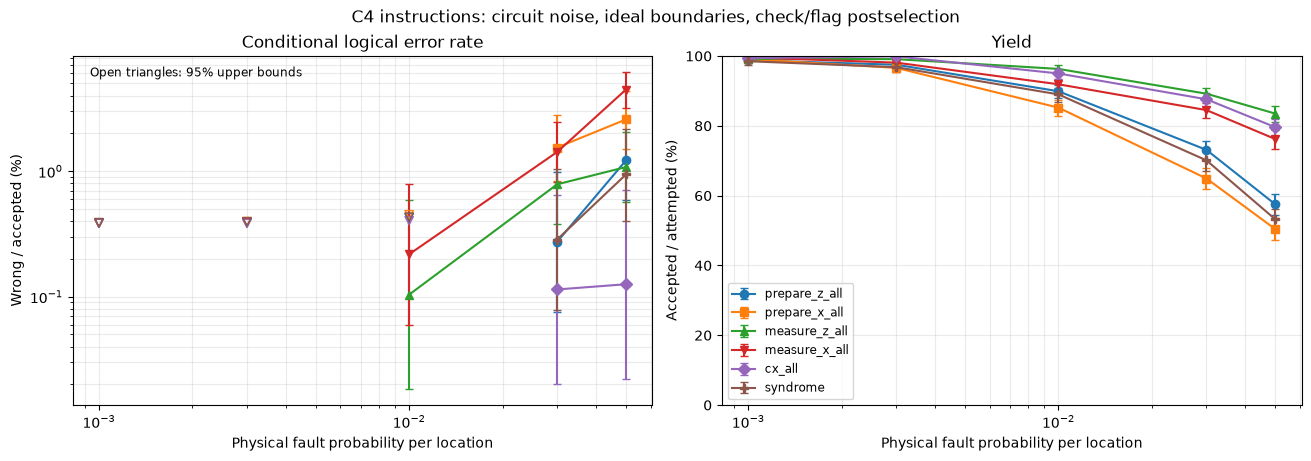

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
metrics = [
    ("wrong", "accepted", "Conditional logical error rate", "Wrong / accepted (%)"),
    ("accepted", "attempted", "Yield", "Accepted / attempted (%)"),
]
markers = ["o", "s", "^", "v", "D", "P"]
for ax, (numerator, denominator, title, ylabel) in zip(axes, metrics):
    for name, marker in zip(instruction_models, markers):
        points = [point for point in sweep if point["instruction"] == name]
        rates = np.array([point[numerator] / point[denominator] for point in points])
        intervals = np.array([
            binomtest(point[numerator], point[denominator]).proportion_ci(
                confidence_level=0.95, method="wilson"
            )
            for point in points
        ])
        errors = np.vstack((rates - intervals[:, 0], intervals[:, 1] - rates))
        probabilities = np.array([point["fault_probability"] for point in points])
        zero_errors = (rates == 0) & (numerator == "wrong")
        curve = ax.errorbar(
            probabilities, 100 * np.where(zero_errors, np.nan, rates),
            yerr=100 * np.where(zero_errors, np.nan, errors),
            fmt=marker + "-", capsize=3, label=name,
        )
        if zero_errors.any():
            ax.scatter(
                probabilities[zero_errors], 100 * intervals[zero_errors, 1],
                marker="v", facecolors="none", edgecolors=curve.lines[0].get_color(),
                zorder=3,
            )
    ax.set(xscale="log", xlabel="Physical fault probability per location", ylabel=ylabel, title=title)
    ax.grid(True, which="both", alpha=0.25)

axes[0].set_yscale("log")
axes[0].text(
    0.03, 0.97, "Open triangles: 95% upper bounds",
    transform=axes[0].transAxes, va="top", fontsize="small",
)
axes[1].set_ylim(0, 100)
axes[1].legend(loc="lower left", fontsize="small")
fig.suptitle("C4 instructions: circuit noise, ideal boundaries, check/flag postselection")
plt.show()

## What we established

We started with the C4 code and built a baseline qodec. We used the audit to find missing equations, then used gadget profiles to find faults and test better circuits. The resulting six gadgets pass the audit and each has distance two. We can also save and load the protocol without changing its declarations.

The sampled plots show conditional logical error rate and yield for every improved instruction under independent circuit-level Pauli, reset, and readout faults. They use ideal boundaries and postselection on checks and flags, not the runtime decoder. The QIR check separately verifies noiseless execution of a logical program. The plots do not compare against the baseline, and 1,000 attempts per point cannot resolve very small error rates.

To assess a complete implementation, we still need noisy end-to-end programs, decoder-confidence selection, instruction-local retries, hardware connectivity and timing, idle and correlated faults, and the cost of the boundary operations that are ideal here.